Total matches: 1218
Toss winners who won the match: 615
Toss winners who lost the match: 603


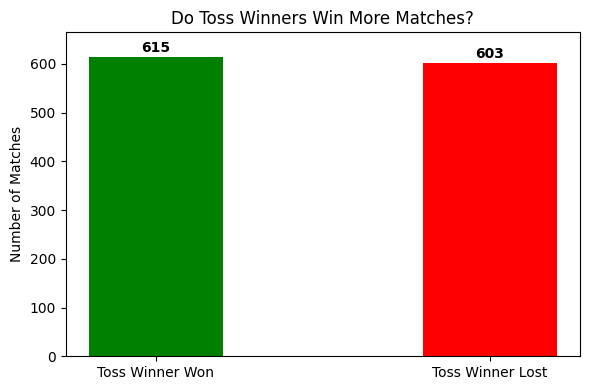

In [3]:
import pandas as pd

df = pd.read_csv("dataset.csv", low_memory=False)


match_df = df[['match_id', 'toss_winner', 'winner']].drop_duplicates()

match_df['toss_won_match'] = match_df['toss_winner'] == match_df['winner']

counts = match_df['toss_won_match'].value_counts()



df['season']

df['match_id'].nunique()

import matplotlib.pyplot as plt

# Step 1: Get one row per match
match_df = df[['match_id', 'toss_winner', 'winner']].drop_duplicates()

# Step 2: Check if toss winner won the match
match_df['toss_won_match'] = match_df['toss_winner'] == match_df['winner']

# Step 3: Count
counts = match_df['toss_won_match'].value_counts()
won = counts[True]
lost = counts[False]
print(f"Total matches: {won + lost}")
print(f"Toss winners who won the match: {counts[True]}")
print(f"Toss winners who lost the match: {counts[False]}")
# Step 4: Plot
plt.figure(figsize=(6, 4))
plt.bar(['Toss Winner Won', 'Toss Winner Lost'], [won, lost], color=['green', 'red'], width=0.4)
plt.title('Do Toss Winners Win More Matches?')
plt.ylabel('Number of Matches')
plt.ylim(0, max(won, lost) + 50)

for i, val in enumerate([won, lost]):
    plt.text(i, val + 10, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

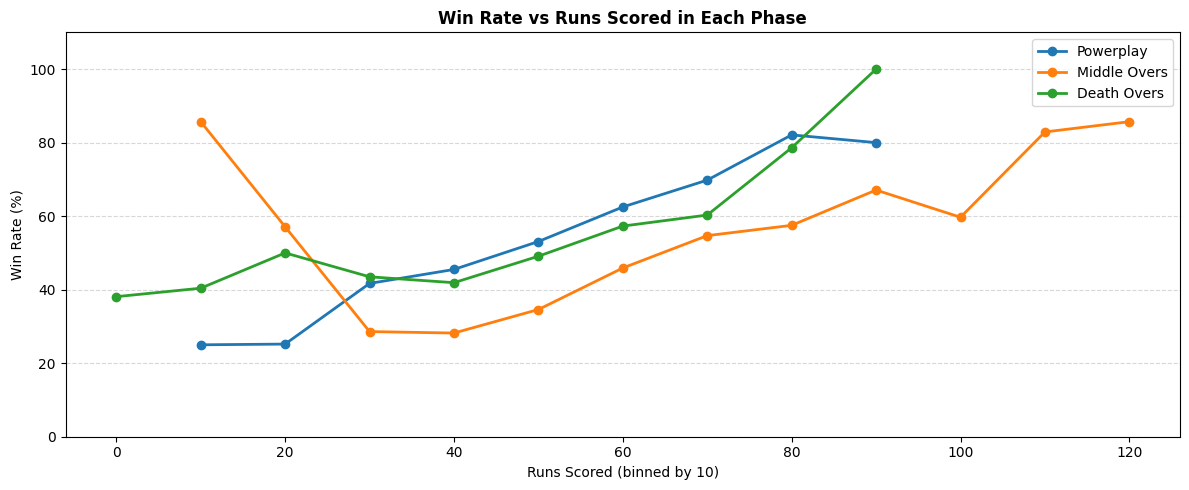

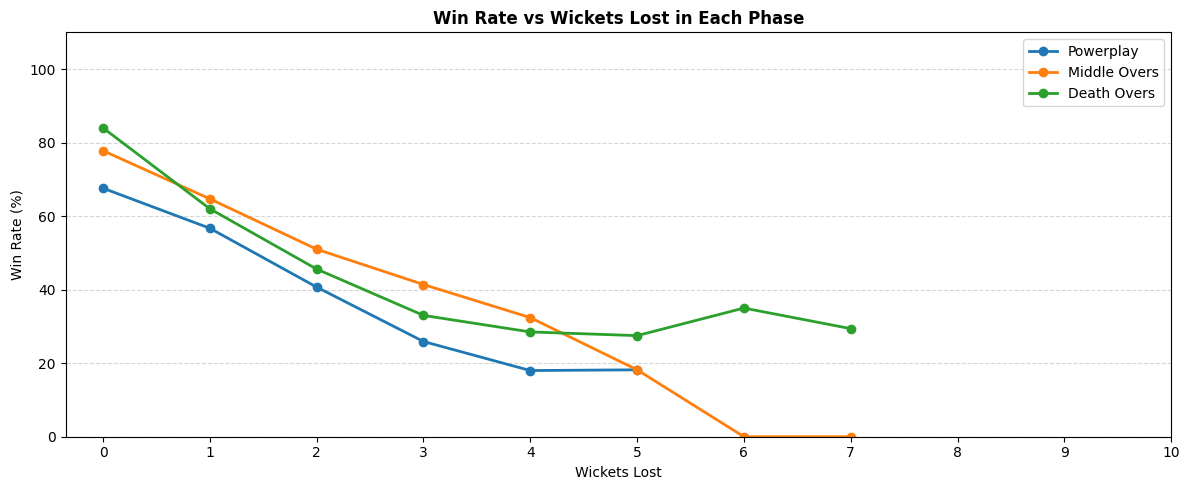

In [8]:
# Recreate helper columns first
def assign_phase(over):
    if over <= 5:
        return 'Powerplay'
    elif over <= 14:
        return 'Middle Overs'
    else:
        return 'Death Overs'

df['phase'] = df['over'].apply(assign_phase)
df['is_wicket'] = df['wicket_player_out'].notna().astype(int)

# Aggregate runs and wickets per match per team per phase
match_phase = df.groupby(['match_id', 'batting_team', 'phase']).agg(
    runs=('runs_total', 'sum'),
    wickets=('is_wicket', 'sum')
).reset_index()

match_phase = match_phase.merge(df[['match_id', 'winner']].drop_duplicates(), on='match_id')
match_phase['won'] = match_phase['batting_team'] == match_phase['winner']

# Helper function
def win_rate_by_value(data, phase, metric):
    sub = data[data['phase'] == phase].copy()
    if metric == 'runs':
        sub['bin'] = (sub['runs'] // 10) * 10
    else:
        sub['bin'] = sub['wickets']
    grouped = sub.groupby('bin')['won'].agg(['sum', 'count'])
    grouped['win_rate'] = (grouped['sum'] / grouped['count'] * 100).round(1)
    grouped = grouped[grouped['count'] >= 5]
    return grouped

phases = ['Powerplay', 'Middle Overs', 'Death Overs']
phase_colors = {'Powerplay': '#1f77b4', 'Middle Overs': '#ff7f0e', 'Death Overs': '#2ca02c'}

# ===== GRAPH 1: Win Rate vs Runs (all 3 phases) =====
plt.figure(figsize=(12, 5))
for phase in phases:
    data = win_rate_by_value(match_phase, phase, 'runs')
    plt.plot(data.index, data['win_rate'], marker='o', linewidth=2,
             label=phase, color=phase_colors[phase])

plt.title('Win Rate vs Runs Scored in Each Phase', fontweight='bold')
plt.xlabel('Runs Scored (binned by 10)')
plt.ylabel('Win Rate (%)')
plt.ylim(0, 110)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ===== GRAPH 2: Win Rate vs Wickets (all 3 phases) =====
plt.figure(figsize=(12, 5))
for phase in phases:
    data = win_rate_by_value(match_phase, phase, 'wickets')
    plt.plot(data.index, data['win_rate'], marker='o', linewidth=2,
             label=phase, color=phase_colors[phase])

plt.title('Win Rate vs Wickets Lost in Each Phase', fontweight='bold')
plt.xlabel('Wickets Lost')
plt.ylabel('Win Rate (%)')
plt.ylim(0, 110)
plt.xticks(range(0, 11))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [10]:
# Compute the summary table
match_phase = df.groupby(['match_id', 'batting_team', 'phase']).agg(
    runs=('runs_total', 'sum'),
    wickets=('is_wicket', 'sum')
).reset_index()

match_phase = match_phase.merge(df[['match_id', 'winner']].drop_duplicates(), on='match_id')
match_phase['won'] = match_phase['batting_team'] == match_phase['winner']

summary = match_phase.groupby(['phase', 'won']).agg(
    avg_runs=('runs', 'mean'),
    avg_wickets=('wickets', 'mean')
).round(2).unstack()

summary.columns = ['Losing Team Runs', 'Winning Team Runs',
                   'Losing Team Wickets', 'Winning Team Wickets']
summary = summary.reindex(['Powerplay', 'Middle Overs', 'Death Overs'])

# Differences
summary['Run Diff (W-L)'] = (summary['Winning Team Runs'] - summary['Losing Team Runs']).round(2)
summary['Wicket Diff (L-W)'] = (summary['Losing Team Wickets'] - summary['Winning Team Wickets']).round(2)

# WEIGHTAGE — normalize differences across phases so they sum to 1
total_run_diff = summary['Run Diff (W-L)'].sum()
total_wkt_diff = summary['Wicket Diff (L-W)'].sum()

summary['Run Weightage'] = (summary['Run Diff (W-L)'] / total_run_diff).round(3)
summary['Wicket Weightage'] = (summary['Wicket Diff (L-W)'] / total_wkt_diff).round(3)

# Final combined weightage (average of both)
summary['Final Weightage'] = ((summary['Run Weightage'] + summary['Wicket Weightage']) / 2).round(3)

# Reorder
summary = summary[['Losing Team Runs', 'Winning Team Runs', 'Run Diff (W-L)', 'Run Weightage',
                   'Losing Team Wickets', 'Winning Team Wickets', 'Wicket Diff (L-W)', 'Wicket Weightage',
                   'Final Weightage']]

# BEAUTIFUL STYLED TABLE
styled = summary.style \
    .background_gradient(subset=['Run Diff (W-L)', 'Run Weightage'], cmap='Greens') \
    .background_gradient(subset=['Wicket Diff (L-W)', 'Wicket Weightage'], cmap='Reds') \
    .background_gradient(subset=['Final Weightage'], cmap='YlOrRd') \
    .format("{:.2f}") \
    .set_caption("Phase-wise Performance & Weightage Analysis") \
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '16px'), ('font-weight', 'bold'),
                   ('color', '#1E293B'), ('padding', '10px'),
                   ('text-align', 'center')]},
        {'selector': 'th',
         'props': [('background-color', '#1E3A8A'), ('color', 'white'),
                   ('font-weight', 'bold'), ('padding', '10px'),
                   ('text-align', 'center'), ('font-size', '12px')]},
        {'selector': 'td',
         'props': [('padding', '10px'), ('text-align', 'center'),
                   ('font-size', '13px'), ('font-family', 'Arial')]},
        {'selector': 'tr:hover td',
         'props': [('background-color', '#F1F5F9')]}
    ])

styled

,Losing Team Runs,Winning Team Runs,Run Diff (W-L),Run Weightage,Losing Team Wickets,Winning Team Wickets,Wicket Diff (L-W),Wicket Weightage,Final Weightage
phase,,,,,,,,,
Powerplay,45.48,51.29,5.81,0.33,1.78,1.11,0.67,0.26,0.30
Middle Overs,66.49,74.33,7.84,0.45,2.73,1.87,0.86,0.33,0.39
Death Overs,43.52,47.24,3.72,0.21,2.79,1.74,1.05,0.41,0.31


Top 5 Batters (by Runs):
      Batter  Total Runs
0    V Kohli        9050
1  RG Sharma        7269
2   S Dhawan        6769
3  DA Warner        6567
4   KL Rahul        5680

Top 5 Bowlers (by Wickets):
      Bowler  Total Wickets
0  YS Chahal            229
1    B Kumar            216
2  SP Narine            203
3  PP Chawla            192
4  JJ Bumrah            189


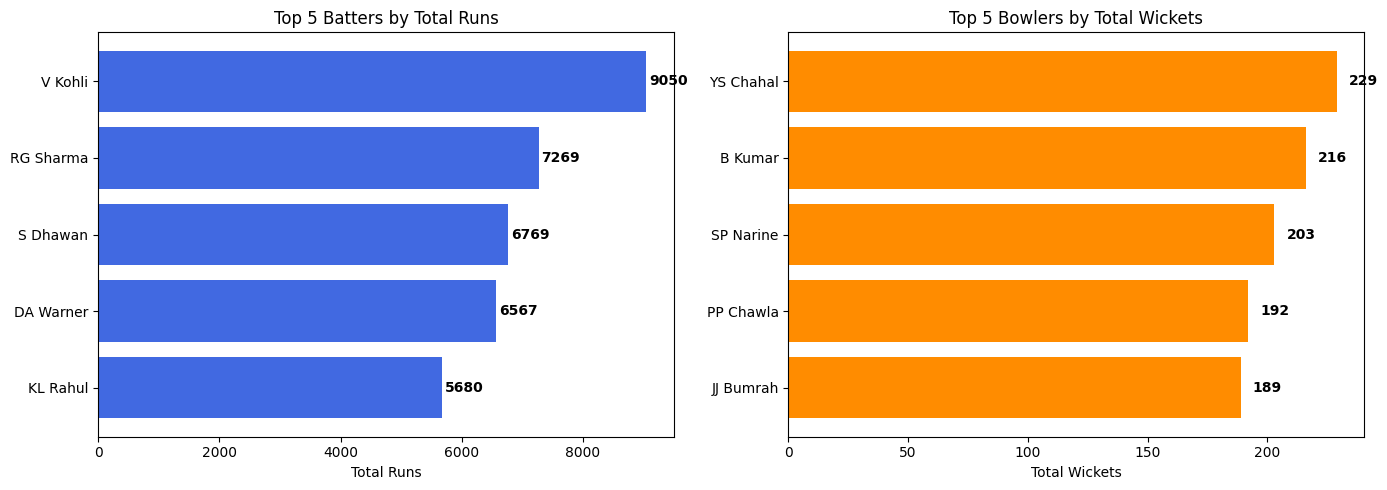

In [11]:
# Top 5 batters by total runs across all seasons
top_batters = df.groupby('batter')['runs_batter'].sum().sort_values(ascending=False).head(5).reset_index()
top_batters.columns = ['Batter', 'Total Runs']
print("Top 5 Batters (by Runs):")
print(top_batters)

# Top 5 bowlers by total wickets across all seasons
# Exclude run-outs (since they aren't credited to the bowler)
bowler_wickets = df[df['wicket_kind'].notna() & (df['wicket_kind'] != 'run out')]
top_bowlers = bowler_wickets.groupby('bowler').size().sort_values(ascending=False).head(5).reset_index()
top_bowlers.columns = ['Bowler', 'Total Wickets']
print("\nTop 5 Bowlers (by Wickets):")
print(top_bowlers)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top_batters['Batter'][::-1], top_batters['Total Runs'][::-1], color='royalblue')
axes[0].set_title('Top 5 Batters by Total Runs')
axes[0].set_xlabel('Total Runs')
for i, val in enumerate(top_batters['Total Runs'][::-1]):
    axes[0].text(val + 50, i, str(val), va='center', fontweight='bold')

axes[1].barh(top_bowlers['Bowler'][::-1], top_bowlers['Total Wickets'][::-1], color='darkorange')
axes[1].set_title('Top 5 Bowlers by Total Wickets')
axes[1].set_xlabel('Total Wickets')
for i, val in enumerate(top_bowlers['Total Wickets'][::-1]):
    axes[1].text(val + 5, i, str(val), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

season_clean
2007    10.74
2009     9.36
2011     8.75
2012     9.91
2013     8.96
2014    11.92
2015    11.73
2016    10.65
2017    11.97
2018    14.53
2019    13.10
2020    12.27
2021    11.45
2022    14.35
2023    15.19
2024    17.76
2025    17.59
2026    18.67
dtype: float64


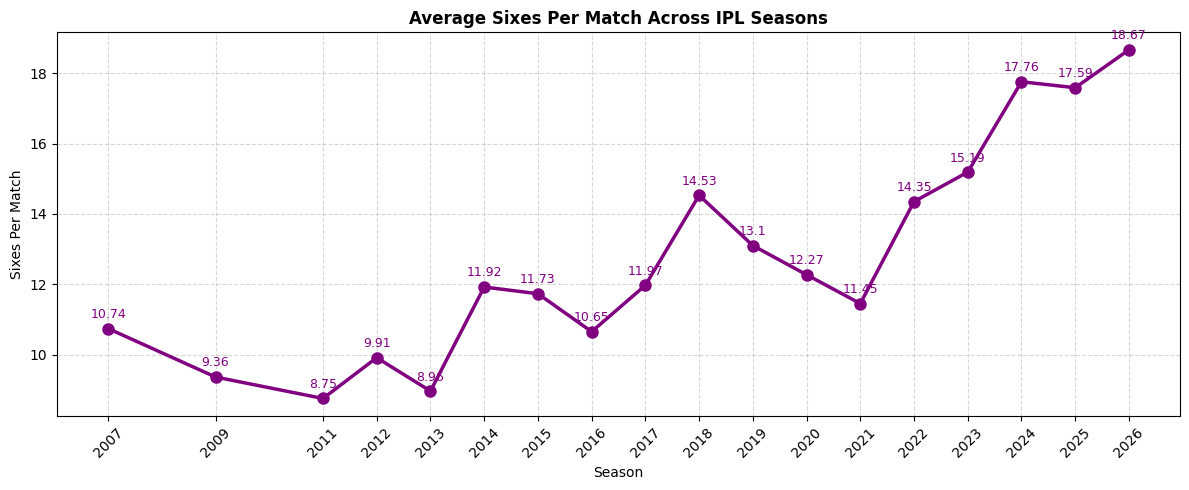

In [12]:
df['season_clean'] = df['season'].astype(str).str[:4].astype(int)

sixes_per_season = df[df['runs_batter'] == 6].groupby('season_clean').size()
matches_per_season = df.groupby('season_clean')['match_id'].nunique()
sixes_per_match = (sixes_per_season / matches_per_season).round(2)

print(sixes_per_match)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(sixes_per_match.index, sixes_per_match.values,
         color='purple', linewidth=2.5, marker='o', markersize=8)

for x, y in zip(sixes_per_match.index, sixes_per_match.values):
    plt.text(x, y + 0.3, f'{y}', ha='center', fontsize=9, color='purple')

plt.title('Average Sixes Per Match Across IPL Seasons', fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Sixes Per Match')
plt.xticks(sixes_per_match.index, rotation=45)
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()